**BEUST Léna**

______________

# **Experiments with Keras functional API on MNIST**

This notebook will guide you through the use of the `keras` functional API. You are going to use the `mnist` dataset from LeCun et al. 1998

We assume you are using TF 2. If you need to install some packages, use `pip install ...`, e.g. `pip install sklearn` for SciKit Learn.

## Loading the packages

In [ ]:
pip install tensorflow

In [ ]:
pip install scikit-learn

In [1]:
# First, import TF and get its version.
import tensorflow as tf
tf_version = tf.__version__

# Check if version >=2.0.0 is used
if not tf_version.startswith('2.'):
    print('WARNING: TensorFlow >= 2.0.0 will be used in this course.\nYour version is {}'.format(tf_version) + '.\033[0m')
else:
    print('OK: TensorFlow >= 2.0.0' + '.\033[0m')

I0000 00:00:1778925357.323846  121046 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778925357.376172  121046 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778925359.582963  121046 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


OK: TensorFlow >= 2.0.0.


In [2]:
import numpy as np
from matplotlib import pyplot as pl

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras import utils
from sklearn import metrics as me

## Loading the raw data
First load the `mnist` dataset and normalize it to be in the range [0, 1]

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

60000 train samples
10000 test samples


The target values of the network are supposed to be 1-hot targets. Now the `y_train` is an array with scalar values as in `[5 0 4 1 ...]` and it should be a 1-hot array `Y_train` as in : 

`[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]...]`
 
Note the change of capital letter in the `Y_train` to denote, per convention, an array with multiple dimensions.

In [4]:
n_classes = 10
Y_train = utils.to_categorical(y_train, n_classes)
Y_test = utils.to_categorical(y_test, n_classes)
print(Y_train[:10])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [ ]:
pip install pydot

In [ ]:
pip install graphviz

## MLP
Here is an example of Multi-Layer Perceptron first defined with the Sequential model then with the functional model. We will also need to tell Keras what is the size of our inputs, in our case a linearized vector of size D=784.

In [5]:
from tensorflow.keras.utils import plot_model
H = 300               # number of neurons
D = X_train.shape[1]  # dimension of input - 784 for MNIST

#Keras sequential model
model1 = Sequential()
model1.add(Input(shape=(D,)))
model1.add(Dense(H, activation='relu'))
model1.add(Dense(n_classes, activation='softmax'))
model1.summary()

#Keras functional API
visible = Input(shape=(D,)) # func api, input is declared
hidden1 = Dense(H, activation='relu')(visible)
output = Dense(n_classes, activation='softmax')(hidden1)
model2 = Model(inputs=visible, outputs=output)
model2.summary()

E0000 00:00:1778925378.186381  121046 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778925378.186652  121614 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778925378.200494  121046 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,510 (931.68 KB)

 Trainable params: 238,510 (931.68 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,510 (931.68 KB)

 Trainable params: 238,510 (931.68 KB)

 Non-trainable params: 0 (0.00 B)

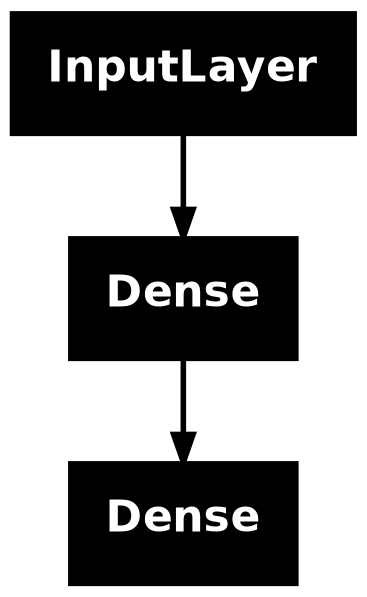

In [6]:
# plot graph - you may need to install pydot module with 'pip install pydot'
#              and also graphviz, see https://graphviz.gitlab.io/download/
plot_model(model2, to_file='multilayer_perceptron_graph.png')

In [7]:
B = 128
E = 10
model2.compile(loss='categorical_crossentropy', optimizer='rmsprop', 
              metrics=['accuracy'])
log = model2.fit(X_train, Y_train, batch_size=B, epochs=E,
                    verbose=1, validation_data=(X_test, Y_test))

Epoch 1/10


W0000 00:00:1778925400.367542  121046 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9186 - loss: 0.2878 - val_accuracy: 0.9558 - val_loss: 0.1476
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9641 - loss: 0.1237 - val_accuracy: 0.9676 - val_loss: 0.1076
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9757 - loss: 0.0830 - val_accuracy: 0.9733 - val_loss: 0.0842
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9813 - loss: 0.0618 - val_accuracy: 0.9771 - val_loss: 0.0766
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9858 - loss: 0.0477 - val_accuracy: 0.9792 - val_loss: 0.0655
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9889 - loss: 0.0380 - val_accuracy: 0.9791 - val_loss: 0.0670
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9910 - loss: 0.0304 - val_accuracy: 0.9787 - val_loss: 0.0698
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9931 - loss: 0.0241 - val_accuracy: 0.9811 - va

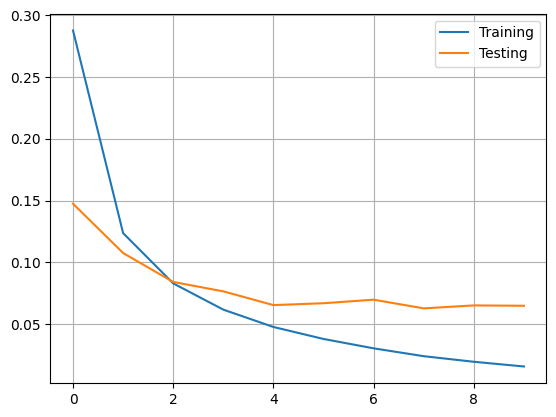

In [8]:
pl.plot(log.history['loss'], label='Training')
pl.plot(log.history['val_loss'], label='Testing')
pl.legend()
pl.grid()

In [9]:
loss_test, metric_test = model2.evaluate(X_test, Y_test)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9817 - loss: 0.0649
Test loss: 0.06491898745298386
Test accuracy: 0.9817000031471252


## Convolutional neural network - CNN

In [10]:
# re-shape the data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        80,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,678 (354.21 KB)

 Trainable params: 90,678 (354.21 KB)

 Non-trainable params: 0 (0.00 B)

None


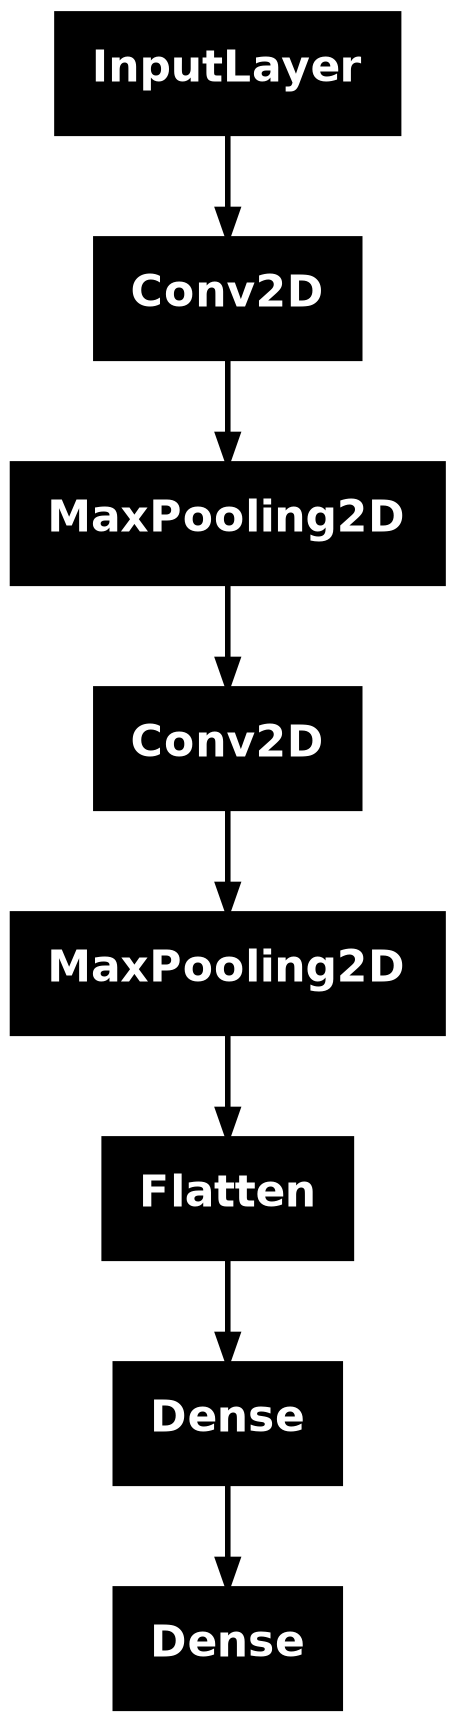

In [11]:
# CNN - Keras functional API
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

visible = Input(shape=(28,28,1))
conv1 = Conv2D(32, kernel_size=3, activation='relu')(visible)
pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
conv2 = Conv2D(32, kernel_size=3, activation='relu')(pool1)
pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
flat = Flatten()(pool2)
hidden1 = Dense(100, activation='relu')(flat)
output = Dense(10, activation='softmax')(hidden1)
model3 = Model(inputs=visible, outputs=output)
# summarize layers
print(model3.summary())
# plot graph
plot_model(model3, to_file='convolutional_neural_network.png')

In [12]:
B = 128
E = 10
model3.compile(loss='categorical_crossentropy', optimizer='rmsprop', 
              metrics=['accuracy'])
log = model3.fit(X_train, Y_train, batch_size=B, epochs=E,
                 verbose=1, validation_data=(X_test, Y_test))

Epoch 1/10


W0000 00:00:1778925789.745249  121046 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9292 - loss: 0.2327 - val_accuracy: 0.9805 - val_loss: 0.0636
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9804 - loss: 0.0642 - val_accuracy: 0.9858 - val_loss: 0.0418
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9869 - loss: 0.0441 - val_accuracy: 0.9895 - val_loss: 0.0309
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9907 - val_loss: 0.0286
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9915 - loss: 0.0265 - val_accuracy: 0.9916 - val_loss: 0.0280
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9934 - loss: 0.0216 - val_accuracy: 0.9915 - val_loss: 0.0264
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.9901 - val_loss: 0.0295
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9955 - loss: 0.0147 - val_accuracy: 0.

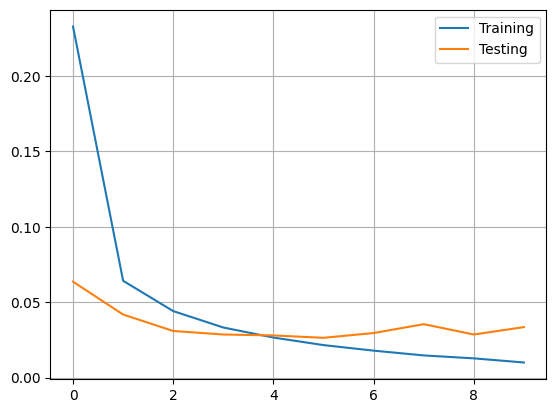

In [13]:
pl.plot(log.history['loss'], label='Training')
pl.plot(log.history['val_loss'], label='Testing')
pl.legend()
pl.grid()

In [14]:
loss_test, metric_test = model3.evaluate(X_test, Y_test)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9897 - loss: 0.0335
Test loss: 0.03346551954746246
Test accuracy: 0.9897000193595886


## Convolutional neural network - CNN with multiple path and shared input layer

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 26, 26,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 23, 23,    │      1,184 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 26, 26,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 23, 23,    │          0 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 13, 13,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 11, 11,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 5408)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3872)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9280)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 100)       │    928,100 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │      1,010 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 930,614 (3.55 MB)

 Trainable params: 930,614 (3.55 MB)

 Non-trainable params: 0 (0.00 B)

None


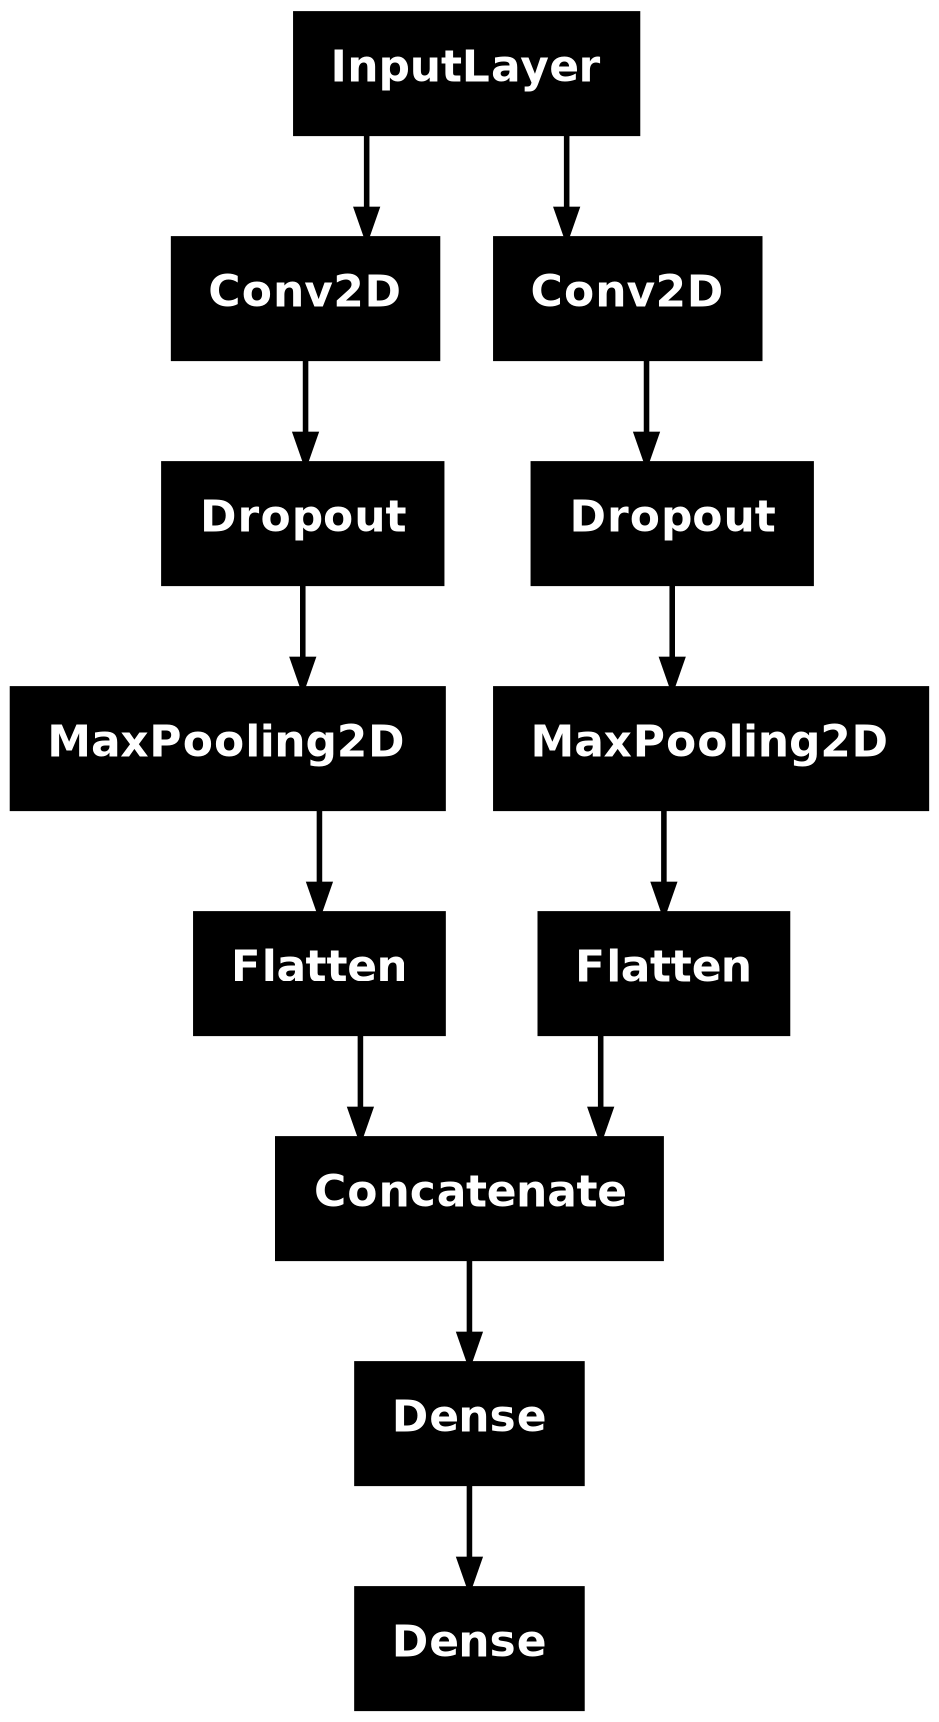

In [15]:
# Shared Input Layer
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.layers import Flatten, Conv2D
from tensorflow.keras.layers import MaxPooling2D, concatenate

# input layer
visible = Input(shape=(28,28,1))
# first feature extractor
conv1 = Conv2D(32, kernel_size=3, activation='relu')(visible)
drop1 = Dropout(0.2)(conv1)
pool1 = MaxPooling2D(pool_size=(2, 2))(drop1)
flat1 = Flatten()(pool1)
# second feature extractor
conv2 = Conv2D(32, kernel_size=6, activation='relu')(visible)
drop2 = Dropout(0.2)(conv2)
pool2 = MaxPooling2D(pool_size=(2, 2))(drop2)
flat2 = Flatten()(pool2)
# merge feature extractors
merge = concatenate([flat1, flat2])
# interpretation layer
hidden1 = Dense(100, activation='relu')(merge)
# prediction output
output = Dense(10, activation='softmax')(hidden1)
model4 = Model(inputs=visible, outputs=output)
# summarize layers
print(model4.summary())
# plot graph
plot_model(model4, to_file='shared_input_layer.png')

In [16]:
B = 128
E = 10
model4.compile(loss='categorical_crossentropy', optimizer='rmsprop', 
              metrics=['accuracy'])
log = model4.fit(X_train, Y_train, batch_size=B, epochs=E,
                 verbose=1, validation_data=(X_test, Y_test))

Epoch 1/10


W0000 00:00:1778925985.986078  121046 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9457 - loss: 0.1808 - val_accuracy: 0.9793 - val_loss: 0.0653
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9841 - loss: 0.0521 - val_accuracy: 0.9878 - val_loss: 0.0395
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9887 - loss: 0.0355 - val_accuracy: 0.9869 - val_loss: 0.0391
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9923 - loss: 0.0257 - val_accuracy: 0.9899 - val_loss: 0.0292
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9937 - loss: 0.0203 - val_accuracy: 0.9877 - val_loss: 0.0371
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9954 - loss: 0.0148 - val_accuracy: 0.9898 - val_loss: 0.0308
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9966 - loss: 0.0119 - val_accuracy: 0.9892 - val_loss: 0.0327
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9971 - loss: 0.0090 - val_accurac

In [17]:
loss_test, metric_test = model4.evaluate(X_test, Y_test)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9907 - loss: 0.0319
Test loss: 0.03189117833971977
Test accuracy: 0.9907000064849854


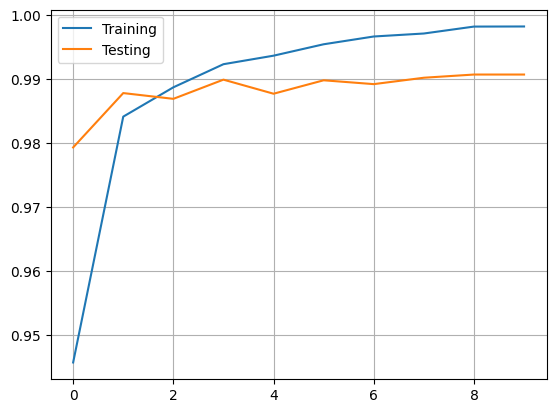

In [18]:
pl.plot(log.history['accuracy'], label='Training')
pl.plot(log.history['val_accuracy'], label='Testing')
pl.legend()
pl.grid()

## Conv neural network - CNN with multiple path, multiple features

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 26, 26,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 26, 26,    │          0 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 13, 13,    │          0 │ dropout_2[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 11, 11,    │      9,248 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 11, 11,    │          0 │ conv2d_5[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 5, 5, 32)  │          0 │ dropout_3[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 3, 3, 32)  │      9,248 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 3, 3, 32)  │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 1, 1, 32)  │          0 │ dropout_4[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 5408)      │          0 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 800)       │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 6240)      │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 100)       │    624,100 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │      1,010 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 643,926 (2.46 MB)

 Trainable params: 643,926 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

None


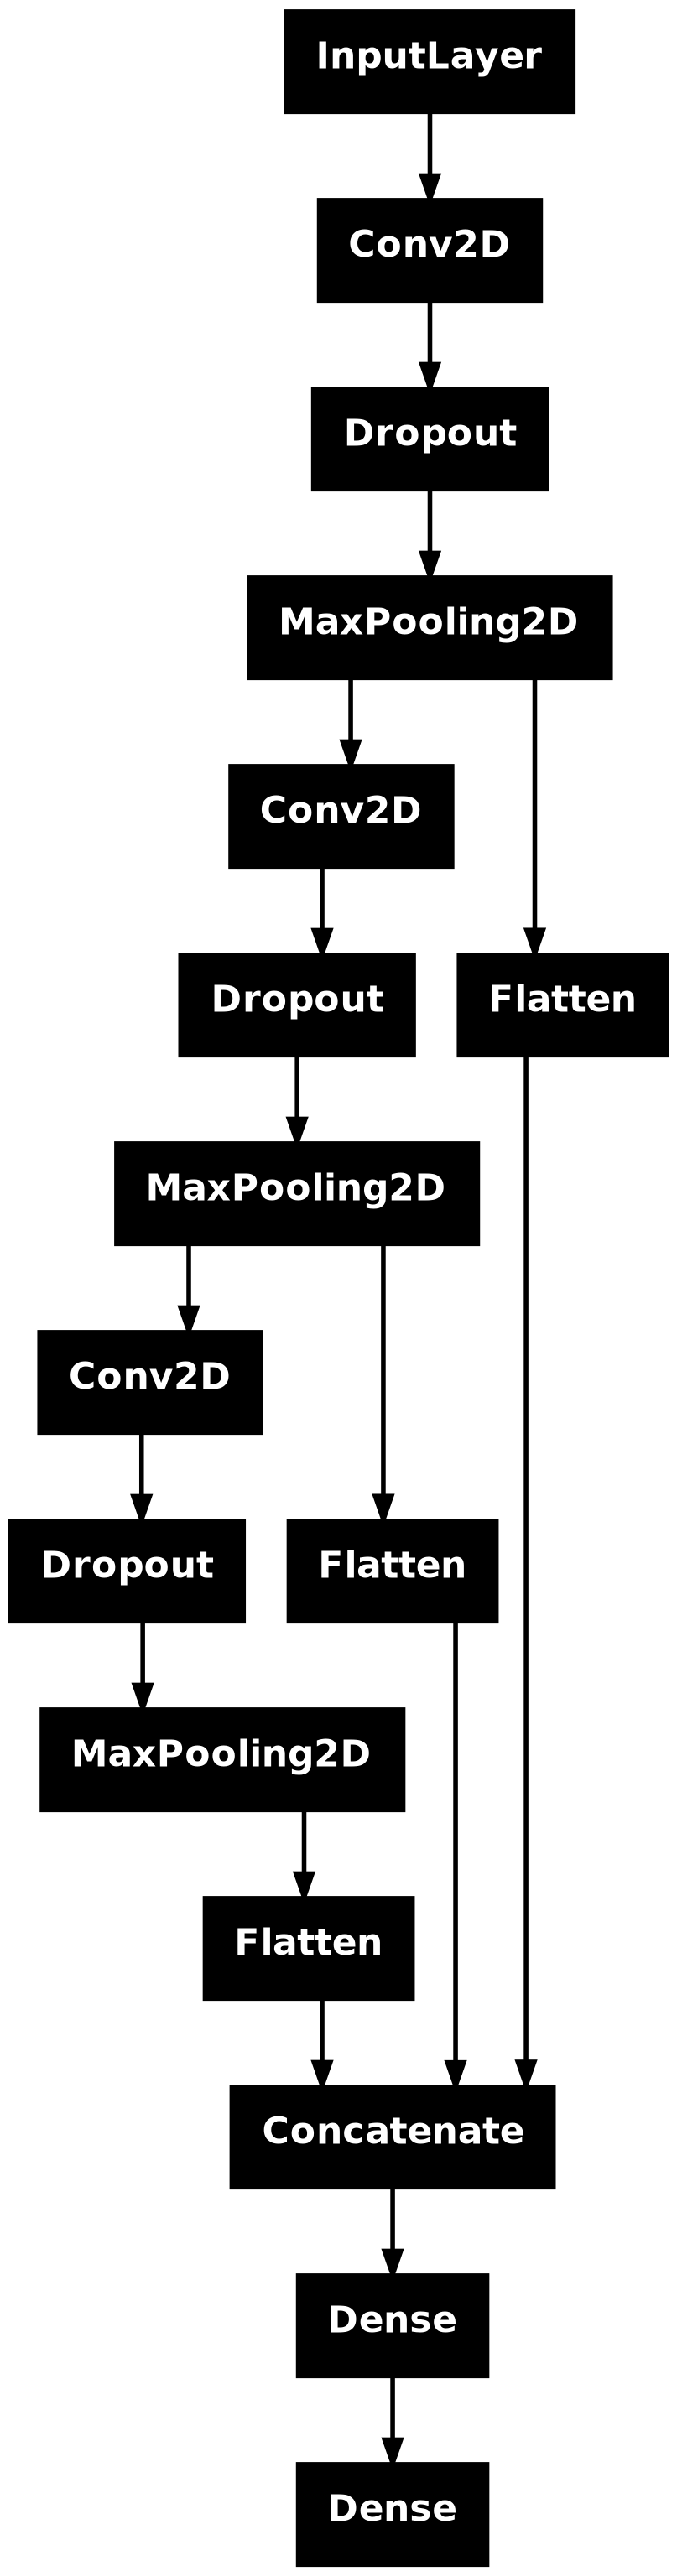

In [19]:
# Shared Input Layer

# input layer
visible = Input(shape=(28,28,1))
# first feature extractor
conv1 = Conv2D(32, kernel_size=3, activation='relu')(visible)
drop1 = Dropout(0.2)(conv1)
pool1 = MaxPooling2D(pool_size=(2, 2))(drop1)
flat1 = Flatten()(pool1)
# second feature extractor
conv2 = Conv2D(32, kernel_size=3, activation='relu')(pool1)
drop2 = Dropout(0.2)(conv2)
pool2 = MaxPooling2D(pool_size=(2, 2))(drop2)
flat2 = Flatten()(pool2)
# third feature extractor
conv3 = Conv2D(32, kernel_size=3, activation='relu')(pool2)
drop3 = Dropout(0.2)(conv3)
pool3 = MaxPooling2D(pool_size=(2, 2))(drop3)
flat3 = Flatten()(pool3)
# merge feature extractors
merge = concatenate([flat1, flat2, flat3])
# interpretation layer
hidden1 = Dense(100, activation='relu')(merge)
# prediction output
output = Dense(10, activation='softmax')(hidden1)
model5 = Model(inputs=visible, outputs=output)
# summarize layers
print(model5.summary())
# plot graph
plot_model(model5, to_file='shared_input_layer_multi_feat.png')

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint

B = 128
E = 10
checkpoint = ModelCheckpoint('model-{epoch:03d}.h5', verbose=1, 
                             monitor='val_accuracy',save_best_only=True, 
                             mode='auto')
model5.compile(loss='categorical_crossentropy', optimizer='rmsprop', 
              metrics=['accuracy'])
log = model5.fit(X_train, Y_train, batch_size=B, epochs=E,
                 verbose=1, validation_data=(X_test, Y_test), 
                 callbacks=[checkpoint])

Epoch 1/10


W0000 00:00:1778926360.237235  121046 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8636 - loss: 0.4256
Epoch 1: val_accuracy improved from None to 0.97870, saving model to model-001.h5



Epoch 1: finished saving model to model-001.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9383 - loss: 0.1983 - val_accuracy: 0.9787 - val_loss: 0.0716
Epoch 2/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9818 - loss: 0.0584
Epoch 2: val_accuracy improved from 0.97870 to 0.98210, saving model to model-002.h5



Epoch 2: finished saving model to model-002.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9828 - loss: 0.0559 - val_accuracy: 0.9821 - val_loss: 0.0684
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9871 - loss: 0.0394
Epoch 3: val_accuracy improved from 0.98210 to 0.98610, saving model to model-003.h5



Epoch 3: finished saving model to model-003.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9878 - loss: 0.0379 - val_accuracy: 0.9861 - val_loss: 0.0453
Epoch 4/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9910 - loss: 0.0294
Epoch 4: val_accuracy improved from 0.98610 to 0.99170, saving model to model-004.h5



Epoch 4: finished saving model to model-004.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9909 - loss: 0.0290 - val_accuracy: 0.9917 - val_loss: 0.0281
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9931 - loss: 0.0202
Epoch 5: val_accuracy did not improve from 0.99170
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9926 - loss: 0.0223 - val_accuracy: 0.9907 - val_loss: 0.0275
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9942 - loss: 0.0180
Epoch 6: val_accuracy did not improve from 0.99170
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9940 - loss: 0.0183 - val_accuracy: 0.9827 - val_loss: 0.0516
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9945 - loss: 0.0161
Epoch 7: val_accuracy did not improve from 0.99170
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9896 - val_loss: 0.0306
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accurac

In [22]:
model5.load_weights(filepath = 'model-004.h5')
loss_test, metric_test = model5.evaluate(X_test, Y_test)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9917 - loss: 0.0281
Test loss: 0.028147513046860695
Test accuracy: 0.9916999936103821


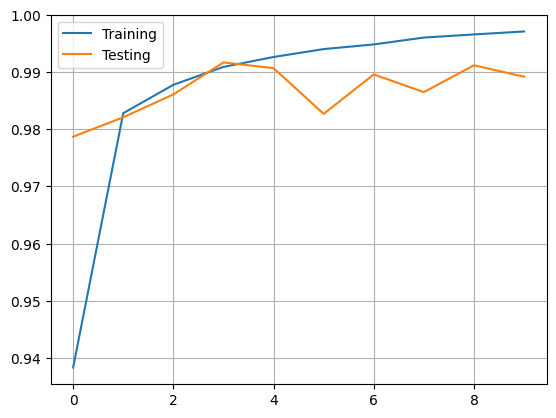

In [23]:
pl.plot(log.history['accuracy'], label='Training')
pl.plot(log.history['val_accuracy'], label='Testing')
pl.legend()
pl.grid()